In [39]:
import logging

import pandas as pd
from mphsweepkit.meta_tex import *
from mphsweepkit.process_data import DataPlot, PlotSettings, PlotTextOverrides

from dimensional_performance_factor.meta import paths

# Logging
logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.WARNING)


# for scaling: 
cm = 1 / 2.54


# Paths:
material_path = paths.material_data
simulation_path = paths.simulation_data
plot_path = paths.grafics
measurements_path = paths.measurement_data

In [40]:
dp = DataPlot.from_result_folder(simulation_path.joinpath("global_data")  )
dp.combined_df

,cut_switch,matsw.comp1.sw1,b_mean,core_temperature,freq,geometry_idx,internal_idx,matsw.comp1.sw1_name,p (core),p (cut),p_el (cut),p_mag (cut),p (frame),p_el (frame),p_mag (frame)
name,,,,,,,,,,,,,,,
unit,1,NaN,T,C,Hz,NaN,NaN,NaN,W,W,W,W,W,W,W
group,Geometry Sweep,Material Sweep,Excitation Sweep,Excitation Sweep,Frequency Sweep,Indexing,Indexing,Derived Metadata,post-processing,post-processing,post-processing,post-processing,post-processing,post-processing,post-processing
0,1.0,1.0,0.05,30.0,100000.0,0,0,N49 (LEA_MTB),0.28318131215804054,0.1161271396460675,0.003656669117068205,0.11247047052899918,0.16705417251197305,0.0026167615093354107,0.1644374110026378
1,1.0,1.0,0.05,30.0,200000.0,0,1,N49 (LEA_MTB),0.7637253484021881,0.31590156722730517,0.019101178791676034,0.29680038843562934,0.447823781174883,0.013649481439156695,0.4341742997357266
2,1.0,1.0,0.05,30.0,300000.0,0,2,N49 (LEA_MTB),1.3862734653068485,0.5784387715334876,0.05191097038389955,0.5265278011495866,0.807834693773361,0.03701259712821871,0.7708220966451425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,2.0,2.0,0.05,90.0,800000.0,1,67,N49 static (LEA_MTB),7.814391120491376,3.1250485405965533,0.023162267401576793,3.1018862731949524,4.689342579894822,0.04751688902611261,4.641825690868696
140,2.0,2.0,0.05,90.0,900000.0,1,68,N49 static (LEA_MTB),9.880474310394192,3.951645511613517,0.02932083163574241,3.9223246799777884,5.928828798780675,0.060151655581176584,5.868677143199497
141,2.0,2.0,0.05,90.0,1000000.0,1,69,N49 static (LEA_MTB),12.448752745170495,4.979444075615567,0.03620750190786949,4.943236573707708,7.469308669554928,0.07428110423867855,7.395027565316244


#### 1. Plot: Simulation CYLINDER vs CUBOID

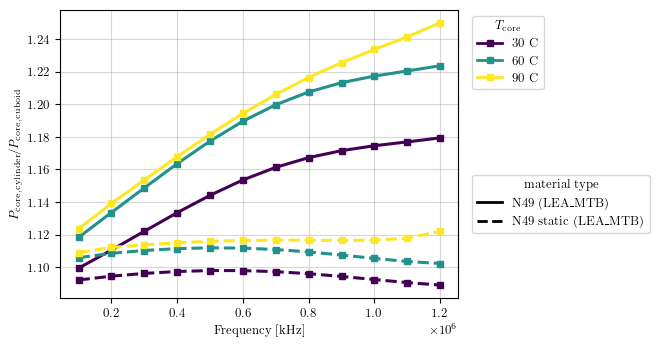

In [41]:
fig, ax = plt.subplots(figsize=(17 / 2.54, 9 / 2.54))

custom_settings = PlotSettings(
    x_scale="linear",
    y_scale="linear",
    show_grid=True,
    grid_which="both",
    grid_alpha=0.5,
    marker="s",
    marker_size=5,
    line_width=2.2,
    color_map_name="viridis",
    line_styles=("-", "--", "-.", ":"),
    show_color_legend=True,
    show_style_legend=True,
    use_tight_layout=True,
    show_title=False
)


dp.ratio_plot(
    ax=ax,
    y_col="p (core)",
    x_col="freq",
    split_col="cut_switch",
    numerator_value="1.0",
    denominator_value="2.0",
    style_col="matsw.comp1.sw1_name",
    color_col="core_temperature",
    settings=custom_settings,
    text_overrides=PlotTextOverrides(
        x_label="Frequency",
        x_unit="kHz",
        y_label=r"$P_\mathrm{core,cylinder} / P_\mathrm{core,cuboid}$",
        y_unit="",
        color_label=r"$T_\mathrm{core}$",
        color_unit="C",
        style_label="material type",
        style_unit=" ",
    ),
)
plt.show()

#### 2. Plot: Simulation vs Measurements

In [42]:
df_meas = pd.read_csv(measurements_path.joinpath("fd_results.csv"), sep=",", decimal=".", index_col=None)
df_meas["p_total"] = df_meas["volume"] * df_meas["p_density_hyst"]
df_meas

,f,T,b,mu_real,mu_imag,p_density_hyst,capacitor,probe_code,primary winding,secondary winding,lmag,cross_section,volume,p_total
0,2.631100e+05,28.415,0.049965,660.663306,21.900624,8.230650e+04,2.203800e-08,F1_F2_CYL3_CYL4,3,3,0.08,0.000177,0.000016,1.309028
1,4.669500e+05,28.389,0.049941,672.259978,27.150536,1.746275e+05,6.838000e-09,F1_F2_CYL3_CYL4,3,3,0.08,0.000177,0.000016,2.777331
2,7.878100e+05,28.420,0.049929,694.138983,46.136723,4.680695e+05,2.238000e-09,F1_F2_CYL3_CYL4,3,3,0.08,0.000177,0.000016,7.444323
3,1.098850e+06,28.537,0.049926,725.730117,88.487574,1.133602e+06,1.038000e-09,F1_F2_CYL3_CYL4,3,3,0.08,0.000177,0.000016,18.029156
4,2.823300e+05,28.610,0.049924,576.925978,15.804754,8.347101e+04,2.203800e-08,F1_F2_CUB3_CUB4,3,3,0.08,0.000177,0.000016,1.327549
5,5.018000e+05,28.602,0.049982,585.221924,19.306324,1.764778e+05,6.838000e-09,F1_F2_CUB3_CUB4,3,3,0.08,0.000177,0.000016,2.806757
6,8.522700e+05,28.943,0.049977,594.881676,31.504489,4.724540e+05,2.238000e-09,F1_F2_CUB3_CUB4,3,3,0.08,0.000177,0.000016,7.514056
7,1.194320e+06,29.865,0.049905,615.122785,52.926186,1.032515e+06,1.038000e-09,F1_F2_CUB3_CUB4,3,3,0.08,0.000177,0.000016,16.421449
8,2.824433e+05,28.378,0.049995,577.748373,15.792101,8.343767e+04,2.203800e-08,F1_F2_CUB3_CUB4,3,3,0.08,0.000177,0.000016,1.327019
9,2.823908e+05,28.413,0.049975,577.516291,15.641577,8.262700e+04,2.203800e-08,F1_F2_CUB3_CUB4,3,3,0.08,0.000177,0.000016,1.314126


In [43]:
dp.combined_df = dp.combined_df[dp.combined_df["matsw.comp1.sw1_name"] != "N49 static (LEA_MTB)"]
dp.combined_df = dp.combined_df[dp.combined_df["core_temperature"] == "30.0"]
dp.combined_df

,cut_switch,matsw.comp1.sw1,b_mean,core_temperature,freq,geometry_idx,internal_idx,matsw.comp1.sw1_name,p (core),p (cut),p_el (cut),p_mag (cut),p (frame),p_el (frame),p_mag (frame)
name,,,,,,,,,,,,,,,
0,1.0,1.0,0.05,30.0,100000.0,0,0,N49 (LEA_MTB),0.28318131215804054,0.1161271396460675,0.003656669117068205,0.11247047052899918,0.16705417251197305,0.0026167615093354107,0.1644374110026378
1,1.0,1.0,0.05,30.0,200000.0,0,1,N49 (LEA_MTB),0.7637253484021881,0.31590156722730517,0.019101178791676034,0.29680038843562934,0.447823781174883,0.013649481439156695,0.4341742997357266
2,1.0,1.0,0.05,30.0,300000.0,0,2,N49 (LEA_MTB),1.3862734653068485,0.5784387715334876,0.05191097038389955,0.5265278011495866,0.807834693773361,0.03701259712821871,0.7708220966451425
3,1.0,1.0,0.05,30.0,400000.0,0,3,N49 (LEA_MTB),2.15054328965875,0.9050318077755697,0.10679624899528287,0.7982355587802867,1.2455114818831803,0.07591730790423708,1.169594173978943
4,1.0,1.0,0.05,30.0,500000.0,0,4,N49 (LEA_MTB),3.0782664931170975,1.3057632956002478,0.18764446026083398,1.1181188353394143,1.77250319751685,0.13288598096568832,1.639617216551164
5,1.0,1.0,0.05,30.0,600000.0,0,5,N49 (LEA_MTB),4.2107129298863475,1.7987288554728071,0.29814639617198896,1.5005824593008215,2.4119840744135406,0.21018266649419975,2.20180140791934
6,1.0,1.0,0.05,30.0,700000.0,0,6,N49 (LEA_MTB),5.6097925910470146,2.4106006332790004,0.4419844429534705,1.9686161903255295,3.199191957768014,0.30993031143903094,2.889261646328989
7,1.0,1.0,0.05,30.0,800000.0,0,7,N49 (LEA_MTB),7.361418143136199,3.1782459628555637,0.623299120470721,2.554946842384835,4.183172180280636,0.43442103323649117,3.7487511470441377
8,1.0,1.0,0.05,30.0,900000.0,0,8,N49 (LEA_MTB),9.580321832464744,4.1510363561333055,0.8471273542655843,3.303909001867723,5.429285476331439,0.5864013607198956,4.842884115611547


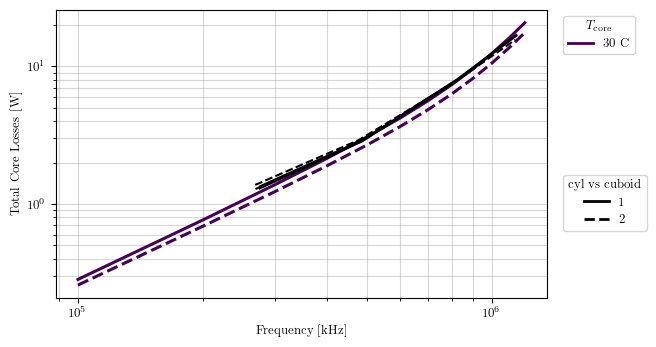

In [44]:
fig, ax = plt.subplots(figsize=(17 / 2.54, 9 / 2.54))  

custom_settings = PlotSettings(
    x_scale="linear",
    y_scale="linear",
    show_grid=True,
    grid_which="both",
    grid_alpha=0.5,
    marker=" ",
    marker_size=5,
    line_width=2.2,
    color_map_name="viridis",
    line_styles=("-", "--", "-.", ":"),
    show_color_legend=True,
    show_style_legend=True,
    use_tight_layout=True,
    show_title=False
)

dp.y_over_x_with_color_and_style(
    ax,
    y_col="p (core)",
    x_col="freq",
    color_col="core_temperature",
    style_col="cut_switch",
    settings=custom_settings,
    text_overrides=PlotTextOverrides(
        x_label="Frequency",
        x_unit="kHz",
        y_label="Total Core Losses",
        y_unit=r"W",
        color_label=r"$T_\mathrm{core}$",
        color_unit="C",
        style_label="cyl vs cuboid",
        style_unit=" "
    )
)


# Integrate measurement data into the plot
ax.loglog(df_meas[28:32]["f"], df_meas[28:32]["p_total"], "-", label="Cylinder",
            color="k", markeredgecolor="black", markeredgewidth=0.8)
ax.loglog(df_meas[32:36]["f"], df_meas[32:36]["p_total"], "-", label="Cylinder",
            color="k", markeredgecolor="black", markeredgewidth=0.8)
ax.loglog(df_meas[36:40]["f"], df_meas[36:40]["p_total"], "--", label="Cuboid", 
            color="k", markeredgecolor="black", markeredgewidth=0.8)
ax.loglog(df_meas[40:43]["f"], df_meas[40:43]["p_total"], "--", label="Cuboid", 
            color="k", markeredgecolor="black", markeredgewidth=0.8)


# plt.savefig(f"toroid_share_of_electrical_losses.pdf", bbox_inches='tight')
plt.show()